STEP 2: SRTM <-> TanDEM-X co-registration on stable terrain

[1/5] Loading & reprojecting to common projected CRS/resolution...
  Working grid: (3715, 3006), resolution 30.0 m, CRS EPSG:32643

[2/5] Rasterizing masks...
  Stable-terrain pixels: 825
  Glacier pixels       : 104,422

[3/5] Computing terrain slope/aspect from TanDEM-X (reference)...

[4/5] Correcting SRTM onto TanDEM-X (stable terrain only, method='nuth_kaab')...
  RAW SRTM-TanDEM-X (stable terrain)
    mean=-36.296 m  median=-35.387 m  NMAD=6.025 m  std=10.474 m  n=825
  iter    dE(m)    dN(m)    dZ(m)   |shift|     NMAD
     1  +53.919  +36.784  -183.754   65.2715    5.845
     2  -41.954  +79.623  +302.217   90.0000   16.304  (bias near bound)
     3  +88.139  -18.209  -302.217   90.0000   47.536  (bias near bound)
     4   -1.814  +89.982  +302.217   90.0000   35.839  (bias near bound)
     5  +83.919  -32.521  -302.217   90.0000  106.398  (bias near bound)
     6  +10.822  +89.347  +302.217   90.0000   55.984  (bias 

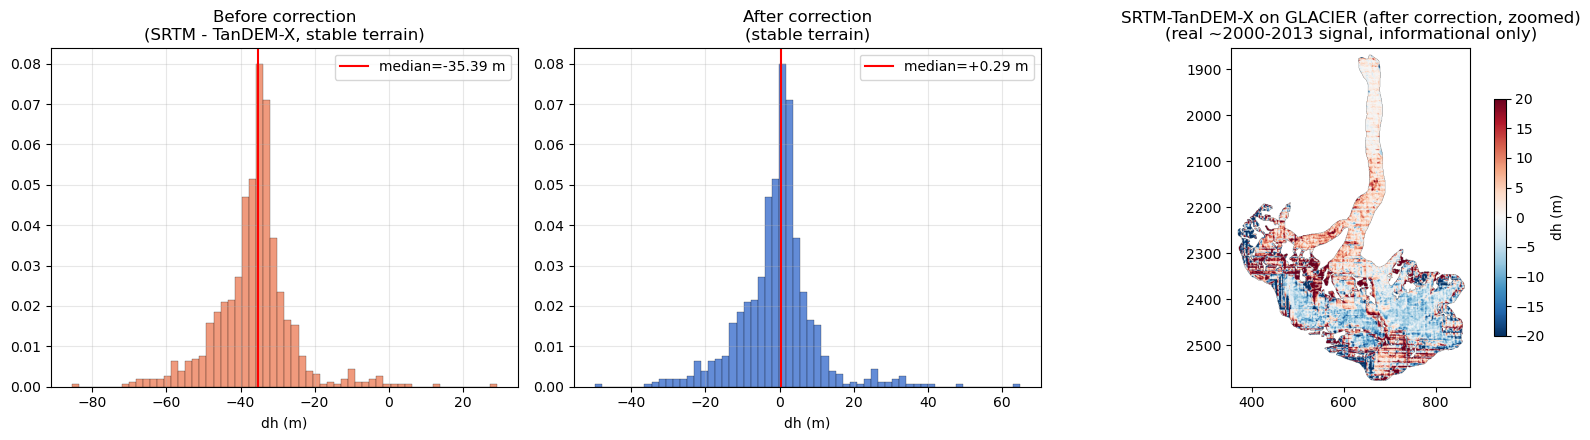


Summary:
  Correction applied (nuth_kaab): {'dE': 0.0, 'dN': 0.0, 'dZ': -35.67839701506455, 'n_iter': 15, 'converged': False, 'fit_grid_res_m': 30.0}
  Output (use as Step 3 reference DEM): D:\thesis\Malangutti\Malangutti\Step2_SRTM_TanDEMX\SRTM_final_corrected.tif


: 

In [ ]:
"""
STEP 2 — SRTM (from Step 1) <-> TanDEM-X co-registration (stable terrain)
==========================================================================
Goal: use TanDEM-X (a globally-consistent, high-accuracy DEM) as a second
independent reference to further tie down SRTM's absolute vertical/
horizontal position, again using stable terrain only.

Output of this step (`SRTM_final_corrected.tif`) is the DEM you should
treat as your "epoch ~2000" reference surface for Step 3 (ASTER
differencing). Keep this file's date fixed at the SRTM acquisition date
(e.g. Feb 2000), NOT the TanDEM-X date — TanDEM-X is only used here to
correct the geometric/vertical bias of SRTM, not to replace SRTM's
elevation values.

IMPORTANT: exactly as in Step 1, the bias/co-registration parameters
are computed on STABLE terrain only. Never fit this using the glacier
(SRTM and TanDEM-X are ~11-15 years apart -> glacier dh there is real
signal, not error).
"""

import os
import numpy as np
import matplotlib.pyplot as plt

from dem_utils import (
    load_dem, reproject_match, rasterize_mask, compute_slope_aspect,
    nuth_kaab_coregister, vertical_bias_correction, print_stats, save_raster,
)

# ============================== CONFIG ======================================
# Use the OUTPUT of Step 1 here (SRTM already corrected against the UAV DEM)
SRTM_INPUT_PATH = r"D:\thesis\Malangutti\Malangutti\Step1_UAV_SRTM\SRTM_corrected_by_UAV_full_extent.tif"
TANDEMX_PATH    = r"D:\thesis\Malangutti\TanXdem\TanXdem.tif"
STABLE_SHP      = r"D:\thesis\Malangutti\Stable Terrain\Stable_terrain.shp"
GLACIER_SHP     = r"D:\thesis\Malangutti\Glacier_RGI_7\Malangutti_Glacier.shp"

OUT_DIR         = r"D:\thesis\Malangutti\Malangutti\Step2_SRTM_TanDEMX"
PROJ_CRS        = "EPSG:32643"     # UTM zone covering Hopper Glacier
TARGET_RES      = 30               # m, common analysis resolution

METHOD          = "nuth_kaab"      # "nuth_kaab" or "vertical"
MAX_DH_COREG    = 200.0
MIN_SLOPE       = 3.0
ZOOM_PAD_PX     = 15                # padding (in pixels) around the glacier
                                     # bounding box for the zoomed plot 3
# =============================================================================

os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 70)
print("STEP 2: SRTM <-> TanDEM-X co-registration on stable terrain")
print("=" * 70)

print("\n[1/5] Loading & reprojecting to common projected CRS/resolution...")
tdx = load_dem(TANDEMX_PATH).rio.reproject(PROJ_CRS, resolution=TARGET_RES)
srtm = reproject_match(load_dem(SRTM_INPUT_PATH), tdx)

res_x, _ = tdx.rio.resolution()
RES_M = abs(res_x)
print(f"  Working grid: {tdx.shape}, resolution {RES_M:.1f} m, CRS {PROJ_CRS}")

print("\n[2/5] Rasterizing masks...")
stable_mask = rasterize_mask(STABLE_SHP, tdx)
glacier_mask = rasterize_mask(GLACIER_SHP, tdx)
print(f"  Stable-terrain pixels: {stable_mask.sum():,}")
print(f"  Glacier pixels       : {glacier_mask.sum():,}")

tdx_arr = tdx.values.astype(float)
srtm_arr = srtm.values.astype(float)

print("\n[3/5] Computing terrain slope/aspect from TanDEM-X (reference)...")
slope, aspect = compute_slope_aspect(tdx_arr, RES_M)

print(f"\n[4/5] Correcting SRTM onto TanDEM-X (stable terrain only, "
      f"method='{METHOD}')...")

dh_raw = srtm_arr - tdx_arr
m_raw = stable_mask & np.isfinite(dh_raw) & (np.abs(dh_raw) < MAX_DH_COREG)
print_stats(dh_raw[m_raw], "RAW SRTM-TanDEM-X (stable terrain)")

if METHOD == "nuth_kaab":
    srtm_final_arr, shift, diag = nuth_kaab_coregister(
        srtm_arr, tdx_arr, slope, aspect, RES_M, stable_mask,
        max_dh=MAX_DH_COREG, min_slope_deg=MIN_SLOPE,
    )
    bias_report = shift
else:
    srtm_final_arr, bias, m = vertical_bias_correction(
        srtm_arr, tdx_arr, stable_mask, max_dh=MAX_DH_COREG,
    )
    bias_report = {"dZ": bias}

dh_post = srtm_final_arr - tdx_arr
m_post = stable_mask & np.isfinite(dh_post) & (np.abs(dh_post) < MAX_DH_COREG)
print_stats(dh_post[m_post], "AFTER correction (stable terrain)")

print("\n[5/5] Saving final 2000-epoch reference DEM and diagnostics...")
out_path = os.path.join(OUT_DIR, "SRTM_final_corrected.tif")
save_raster(srtm_final_arr, tdx, PROJ_CRS, out_path)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(dh_raw[m_raw], bins=60, color="#ee8866", alpha=0.85,
             edgecolor="k", lw=0.2, density=True)
axes[0].axvline(np.median(dh_raw[m_raw]), color="red", lw=1.5,
                 label=f"median={np.median(dh_raw[m_raw]):+.2f} m")
axes[0].set_title("Before correction\n(SRTM - TanDEM-X, stable terrain)")
axes[0].set_xlabel("dh (m)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(dh_post[m_post], bins=60, color="#4878d0", alpha=0.85,
             edgecolor="k", lw=0.2, density=True)
axes[1].axvline(np.median(dh_post[m_post]), color="red", lw=1.5,
                 label=f"median={np.median(dh_post[m_post]):+.2f} m")
axes[1].set_title("After correction\n(stable terrain)")
axes[1].set_xlabel("dh (m)"); axes[1].legend(); axes[1].grid(alpha=0.3)

# --- Plot 3: zoom in on the glacier's own bounding box, not the full ------
# working grid, so the glacier actually fills the panel instead of
# appearing as a tiny speck against mostly empty space.
rows_with_glacier = np.where(glacier_mask.any(axis=1))[0]
cols_with_glacier = np.where(glacier_mask.any(axis=0))[0]

if rows_with_glacier.size and cols_with_glacier.size:
    r0 = max(0, rows_with_glacier.min() - ZOOM_PAD_PX)
    r1 = min(glacier_mask.shape[0], rows_with_glacier.max() + ZOOM_PAD_PX)
    c0 = max(0, cols_with_glacier.min() - ZOOM_PAD_PX)
    c1 = min(glacier_mask.shape[1], cols_with_glacier.max() + ZOOM_PAD_PX)
else:
    r0, r1, c0, c1 = 0, glacier_mask.shape[0], 0, glacier_mask.shape[1]

dh_gl_plot = np.where(glacier_mask, dh_post, np.nan)[r0:r1, c0:c1]
vmax = min(20, np.nanpercentile(np.abs(dh_gl_plot[np.isfinite(dh_gl_plot)]), 98)
           if np.any(np.isfinite(dh_gl_plot)) else 20)
im = axes[2].imshow(dh_gl_plot, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                     extent=[c0, c1, r1, r0])
axes[2].set_title("SRTM-TanDEM-X on GLACIER (after correction, zoomed)\n"
                   "(real ~2000-2013 signal, informational only)")
plt.colorbar(im, ax=axes[2], shrink=0.7, label="dh (m)")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "step2_diagnostics.png"), dpi=150)
plt.show()

print("\nSummary:")
print(f"  Correction applied ({METHOD}): {bias_report}")
print(f"  Output (use as Step 3 reference DEM): {out_path}")